In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# data load
df = pd.read_csv('ifood_df.csv')
print(df.shape)
print(df.head())

(2205, 39)
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4               46                27            15  ...                 0   

   marital_Widow  education_2n Cycle  educati

## 1. Response rate of campaign

In [ ]:
# Total response rate
response_rate = df['Response'].mean()
print(f"Total response rate: {response_rate:.1%}")

# Number of Responders vs. Non-responders
response_counts = df['Response'].value_counts()
print("Responders:", response_counts[1])
print("Non-responders:", response_counts[0])

Total response rate: 15.1%
Responders: 333
Non-responders: 1872


## 2. Set income group

Income group
low         0.104882
mid-low     0.125455
mid-high    0.103448
high        0.270417
Name: Response, dtype: float64


/tmp/ipykernel_7779/3040169846.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_response = df.groupby('Income group')['Response'].mean()


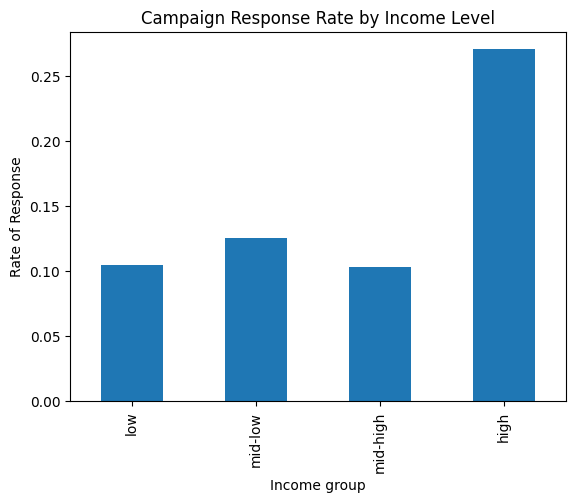

In [ ]:
# Divide income into 4 brackets
df['Income group'] = pd.qcut(df['Income'], 4, labels=['low', 'mid-low', 'mid-high', 'high'])

# Response rate by income
income_response = df.groupby('Income group')['Response'].mean()
print(income_response)
income_response.plot(kind='bar')
plt.title('Campaign Response Rate by Income Level')
plt.ylabel('Rate of Response')
plt.show()

## 3. Purchasing patterns by age group

/tmp/ipykernel_7779/186296825.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby('Age_group')[['MntTotal', 'NumWebPurchases',


             MntTotal  NumWebPurchases  NumStorePurchases
Age_group                                                
20s        751.426230         3.590164           5.754098
30s        490.689076         3.425770           5.226891
40s        482.242091         3.866575           5.474553
50s(+)     631.408491         4.517925           6.267925


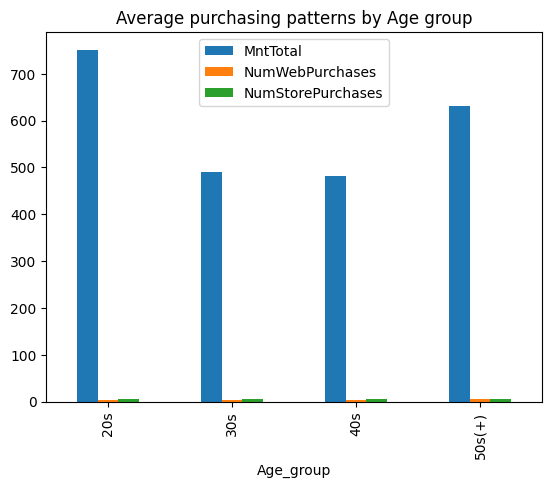

In [ ]:
# Age grouping
df['Age_group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 100],
                         labels=['20s', '30s', '40s', '50s(+)'])

# Purchase Amount & Channel Usage by Age Group
age_summary = df.groupby('Age_group')[['MntTotal', 'NumWebPurchases',
                                       'NumStorePurchases']].mean()
print(age_summary)
age_summary.plot(kind='bar')
plt.title('Average purchasing patterns by Age group')
plt.show()

## 4. Consumption differences based on presence or absence of children

Average purchase amount with children vs. without children: [1041.20700637  372.23715916]


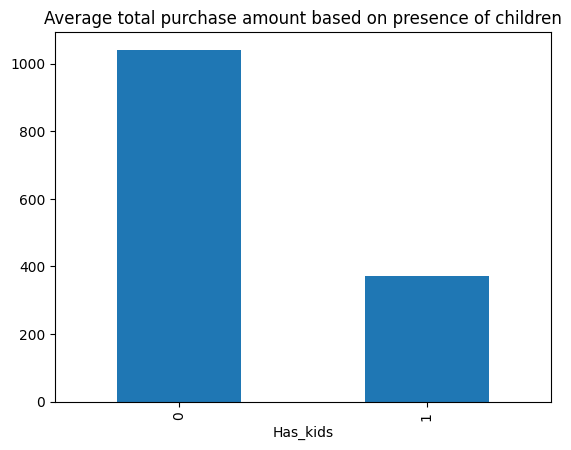

In [ ]:
# Whether or not there are children
df['Has_kids'] = (df['Kidhome'] + df['Teenhome'] > 0).astype(int)

# Purchase comparison based on presence of children
kids_comparison = df.groupby('Has_kids')['MntTotal'].mean()
print("Average purchase amount with children vs. without children:", kids_comparison.values)

kids_comparison.plot(kind='bar')
plt.title('Average total purchase amount based on presence of children')
plt.show()

## 5. Web Visits and Purchase Relationship

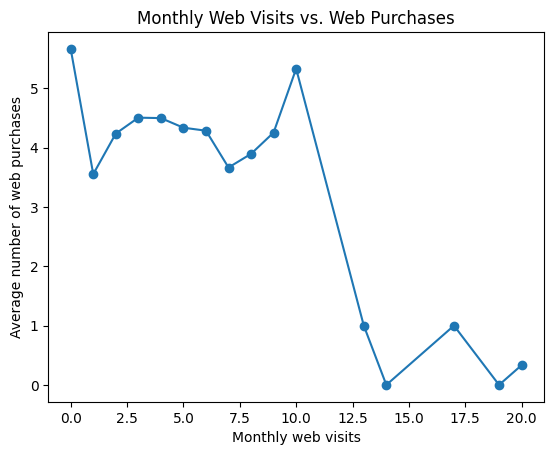

In [ ]:
# Average web purchases by number of web visits
web_visit_purchase = df.groupby('NumWebVisitsMonth')['NumWebPurchases'].mean()
plt.plot(web_visit_purchase.index, web_visit_purchase.values, 'o-')
plt.title('Monthly Web Visits vs. Web Purchases')
plt.xlabel('Monthly web visits')
plt.ylabel('Average number of web purchases')
plt.show()

## 6. Main customers by channel

Main channel distribution: Main_channel
NumStorePurchases      1458
NumWebPurchases         592
NumCatalogPurchases     155
Name: count, dtype: int64


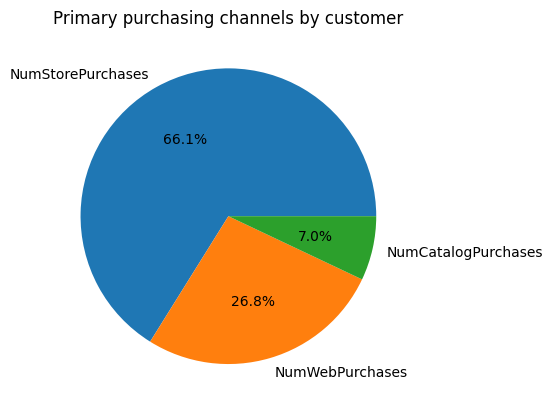

In [ ]:
# Main channel division
df['Main_channel'] = df[['NumWebPurchases', 'NumCatalogPurchases',
                        'NumStorePurchases']].idxmax(axis=1)

channel_dist = df['Main_channel'].value_counts()
print("Main channel distribution:", channel_dist)

channel_dist.plot(kind='pie', autopct='%1.1f%%')
plt.title('Primary purchasing channels by customer')
plt.ylabel('')
plt.show()

## 7. Performance by campaign

Response rate for each campaign:
 AcceptedCmp4    0.074376
AcceptedCmp3    0.073923
AcceptedCmp5    0.073016
AcceptedCmp1    0.064399
AcceptedCmp2    0.013605
dtype: float64


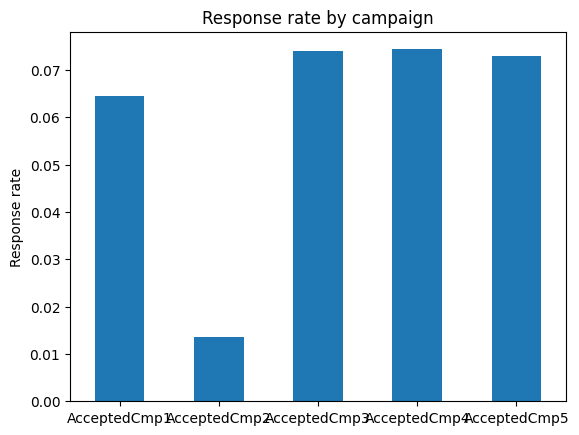

In [ ]:
# Response rate for each campaign
campaign_cols = [f'AcceptedCmp{i}' for i in range(1,6)]
campaign_rates = df[campaign_cols].mean()
print("Response rate for each campaign:\n", campaign_rates.sort_values(ascending=False))

campaign_rates.plot(kind='bar')
plt.title('Response rate by campaign')
plt.ylabel('Response rate')
plt.xticks(rotation=0)
plt.show()

## 8. Recent visit date and purchase amount

Recency_group
Recent    552.037711
Medium    570.238227
Old       566.760504
Name: MntTotal, dtype: float64


/tmp/ipykernel_7779/477958890.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recency_mnt = df.groupby('Recency_group')['MntTotal'].mean()


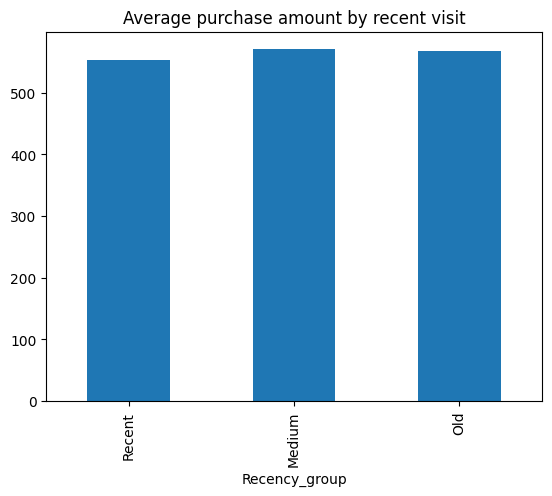

In [ ]:
# Purchase amount by Recency visit
df['Recency_group'] = pd.cut(df['Recency'], 3, labels=['Recent', 'Medium', 'Old'])
recency_mnt = df.groupby('Recency_group')['MntTotal'].mean()
print(recency_mnt)

recency_mnt.plot(kind='bar')
plt.title('Average purchase amount by recent visit')
plt.show()

## 9. Relationship between income&total expenditure and campaign response

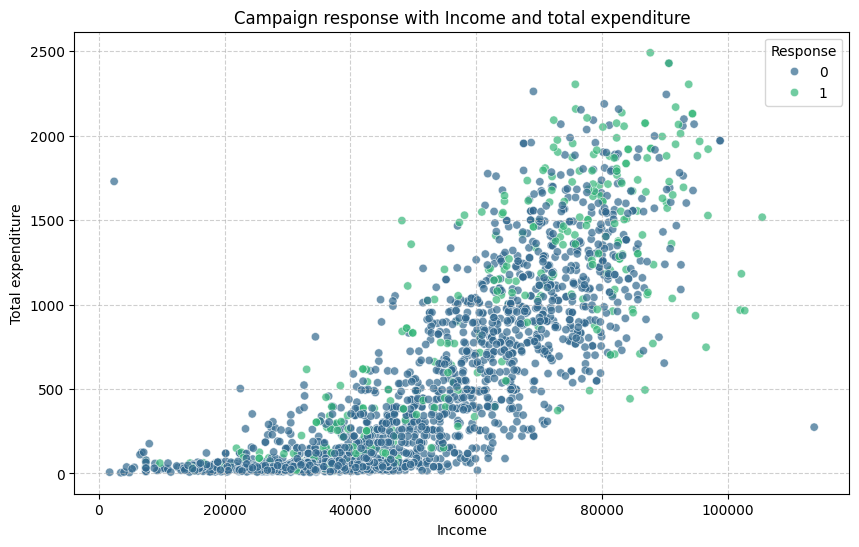

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='MntTotal', hue='Response', palette='viridis', alpha=0.7)
plt.title('Campaign response with Income and total expenditure')
plt.xlabel('Income')
plt.ylabel('Total expenditure')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 10. Comparison of campaign response rates based on recent visit (Recency)

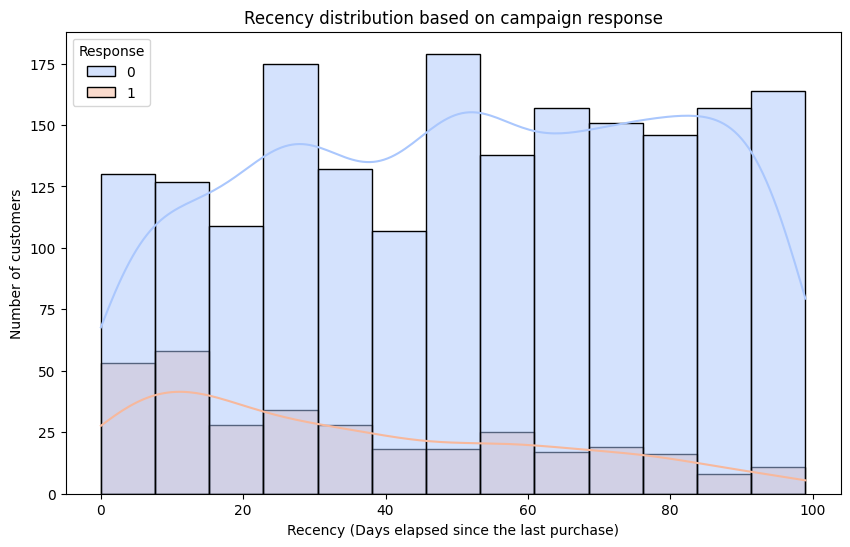

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Recency', hue='Response', kde=True, palette='coolwarm')
plt.title('Recency distribution based on campaign response')
plt.xlabel('Recency (Days elapsed since the last purchase)')
plt.ylabel('Number of customers')
plt.show()

## 11. VIP Customer Features

In [ ]:
# Top 20% VIP customers
vip_threshold = df['MntTotal'].quantile(0.8)
vip_customers = df[df['MntTotal'] >= vip_threshold]

print("VIP Customer Features:")
print("Average Income:", vip_customers['Income'].mean())
print("Average Age:", vip_customers['Age'].mean())
print("Rate of 'having kids':", vip_customers['Has_kids'].mean())
print("Proportion of web purchases:", vip_customers['NumWebPurchases'].mean() /
      (vip_customers[['NumWebPurchases','NumStorePurchases']].sum(axis=1).mean()))

VIP Customer Features:
Average Income: 76177.78004535148
Average Age: 51.98639455782313
Rate of 'having kids': 0.2789115646258503
Proportion of web purchases: 0.3951338199513382


## 12. Model of response prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Predictor selection
features = ['Income', 'Age', 'NumWebPurchases', 'NumStorePurchases',
           'NumWebVisitsMonth', 'Recency', 'Kidhome', 'Teenhome']
X = df[features].fillna(0)
y = df['Response']

# Model training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Variable Importance
importances = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("Response predicted Important Variables:\n", importances)

# Result of prediction
y_pred = model.predict(X_test)
print("\nmodel performance:")
print(classification_report(y_test, y_pred))

Response predicted Important Variables:
              feature  importance
0             Income    0.254031
5            Recency    0.203986
1                Age    0.151841
3  NumStorePurchases    0.113171
2    NumWebPurchases    0.110012
4  NumWebVisitsMonth    0.106401
7           Teenhome    0.037574
6            Kidhome    0.022985

model performance:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       378
           1       0.64      0.29      0.40        63

    accuracy                           0.88       441
   macro avg       0.77      0.63      0.66       441
weighted avg       0.86      0.88      0.85       441



## 13. RFM Analysis

--- RFM Segment Analysis Report ---
            Segment    Recency  Frequency     Monetary  Response  Count
2         Champions  19.405797  23.568841  1151.188406  0.297101    276
1           At Risk  78.330579  22.578512  1055.909091  0.140496    363
4   Loyal Customers  34.258383  18.467456   742.057199  0.216963    507
0    About to Sleep  64.187500  10.852273   331.338068  0.073864    352
3  Lost/Hibernating  79.716374   7.055556    70.459064  0.032164    342
5  Recent Customers  19.312329   6.934247    62.800000  0.145205    365


/tmp/ipykernel_7779/3721919839.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_analysis, x='Segment', y='Count', palette='viridis')


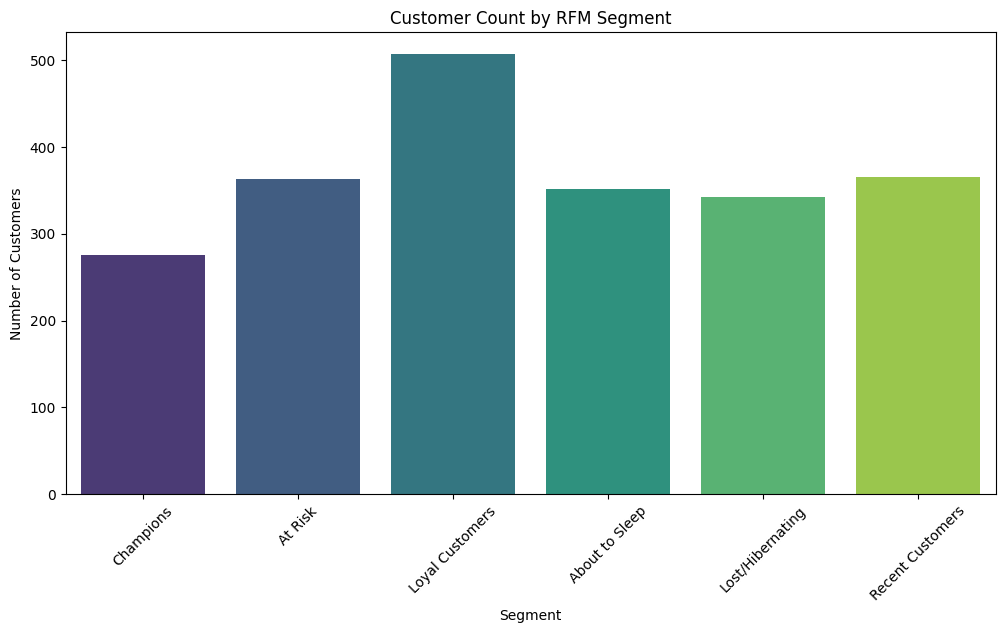

/tmp/ipykernel_7779/3721919839.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_analysis.sort_values('Response', ascending=False),


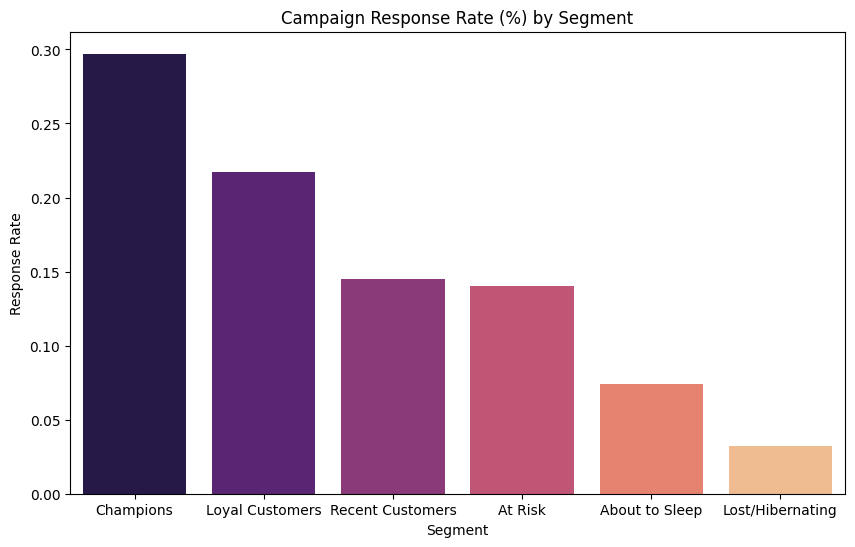

In [ ]:
# 1. RFM Metrics Calculation
# Recency: Days since last purchase (lower is better)
# Frequency: Sum of purchases across all channels
df['Frequency'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + \
                  df['NumStorePurchases'] + df['NumDealsPurchases']
# Monetary: Total amount spent (MntTotal)
df['Monetary'] = df['MntTotal']

# 2. RFM Scoring (Scale of 1 to 5)
df['R_Score'] = pd.qcut(df['Recency'], 5, labels=[5, 4, 3, 2, 1])
df['F_Score'] = pd.qcut(df['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
df['M_Score'] = pd.qcut(df['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 3. Defining Segment Logic
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost/Hibernating'
    else:
        return 'About to Sleep'

df['Segment'] = df.apply(segment_customer, axis=1)

# 4. Segment Summary Analysis
segment_analysis = df.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Response': 'mean',      # Campaign Conversion Rate
    'MntTotal': 'count'      # Customer Count
}).rename(columns={'MntTotal': 'Count'}).reset_index()

# Sort by Monetary value to see high-value segments first
segment_analysis = segment_analysis.sort_values(by='Monetary', ascending=False)

print("--- RFM Segment Analysis Report ---")
print(segment_analysis)

# 5. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=segment_analysis, x='Segment', y='Count', palette='viridis')
plt.title('Customer Count by RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_analysis.sort_values('Response', ascending=False),
            x='Segment', y='Response', palette='magma')
plt.title('Campaign Response Rate (%) by Segment')
plt.ylabel('Response Rate')
plt.show()


## 14. Correlation Analysis and Heatmap

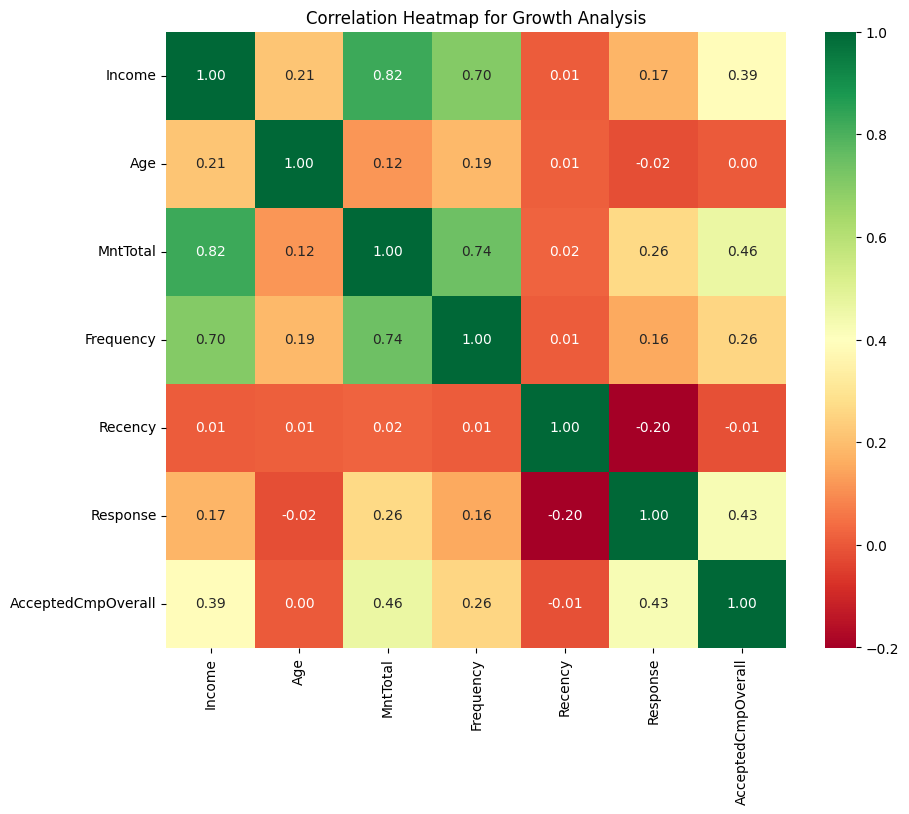

In [ ]:
import seaborn as sns

# Analyzing correlation coefficients of major variables
cols_to_check = ['Income', 'Age', 'MntTotal', 'Frequency', 'Recency', 'Response', 'AcceptedCmpOverall']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap for Growth Analysis')
plt.show()

## 15. Campaign Efficiency Analysis (LTV Perspective)

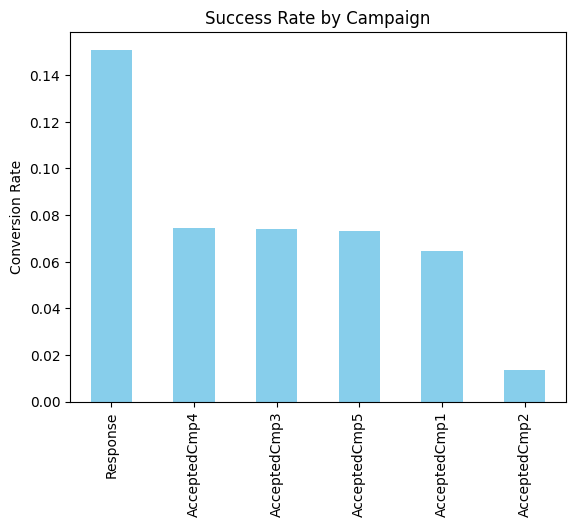

Number of loyal customers who participated in campaigns two or more times: 236


In [ ]:
# Comparison of response rates by campaign
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_success = df[campaign_cols].mean().sort_values(ascending=False)

campaign_success.plot(kind='bar', color='skyblue')
plt.title('Success Rate by Campaign')
plt.ylabel('Conversion Rate')
plt.show()

# Analysis of Loyal Customers
df['Total_Accepted'] = df['AcceptedCmpOverall'] + df['Response']
loyal_customers = df[df['Total_Accepted'] >= 2]
print(f"Number of loyal customers who participated in campaigns two or more times: {len(loyal_customers)}")

## 16. Conversion prediction model

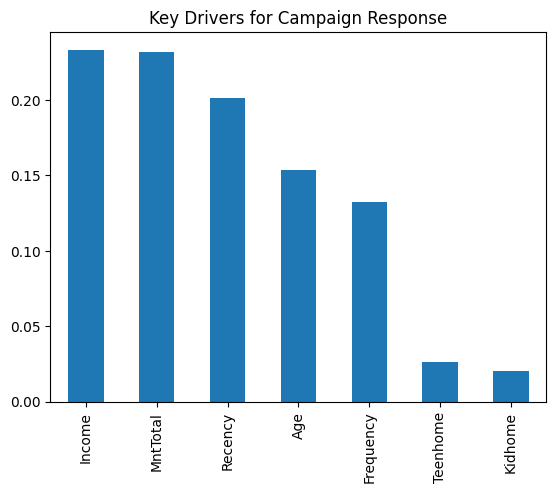

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Feature selection for model training
features = ['Income', 'Kidhome', 'Teenhome', 'Recency', 'Age', 'MntTotal', 'Frequency']
X = df[features]
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Identify key variables (Which factors contribute the most to conversion?)
feature_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
feature_importances.plot(kind='bar')
plt.title('Key Drivers for Campaign Response')
plt.show()

## 17. Function of predict customer response

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Data Preparation
df = pd.read_csv('ifood_df.csv')
df['Frequency'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + \
                  df['NumStorePurchases'] + df['NumDealsPurchases']

# Selecting a comprehensive feature set
features = [
    'Income', 'Kidhome', 'Teenhome', 'Recency', 'Age', 'MntTotal', 'Frequency',
    'AcceptedCmpOverall', 'NumWebVisitsMonth', 'Customer_Days'
]
# Include encoded categorical variables (Education and Marital Status)
categorical_cols = [col for col in df.columns if 'marital_' in col or 'education_' in col]
features += categorical_cols

X = df[features]
y = df['Response']

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Training the Gradient Boosting Model
# HistGradientBoosting is optimized for speed and accuracy
model_hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_depth=5,
    l2_regularization=0.1,
    random_state=42
)
model_hgb.fit(X_train, y_train)

# 4. Evaluation
y_proba = model_hgb.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

ROC-AUC Score: 0.8667


In [ ]:
def predict_customer_advanced(data_dict):
    """
    Predicts campaign response probability using the trained HistGB model.
    Input: Dictionary containing customer features.
    """
    # Convert input to DataFrame
    input_df = pd.DataFrame([data_dict])

    # Perform prediction
    prediction = model_hgb.predict(input_df)[0]
    probability = model_hgb.predict_proba(input_df)[0][1]

    status = "High Potential (Target)" if prediction == 1 else "Low Potential (Exclude)"

    print(f"--- Customer Analysis ---")
    print(f"Prediction: {status}")
    print(f"Response Probability: {probability:.2%}")
    print(f"--------------------------")

    return prediction, probability

# Example Usage:
new_customer = {
    'Income': 75000, 'Kidhome': 0, 'Teenhome': 0, 'Recency': 10, 'Age': 35,
    'MntTotal': 1200, 'Frequency': 25, 'AcceptedCmpOverall': 1,
    'NumWebVisitsMonth': 3, 'Customer_Days': 2500,
    'marital_Divorced': 0, 'marital_Married': 1, 'marital_Single': 0,
    'marital_Together': 0, 'marital_Widow': 0,
    'education_2n Cycle': 0, 'education_Basic': 0, 'education_Graduation': 1,
    'education_Master': 0, 'education_PhD': 0
}

predict_customer_advanced(new_customer)

--- Customer Analysis ---
Prediction: High Potential (Target)
Response Probability: 84.52%
--------------------------


(np.int64(1), np.float64(0.8452430573391148))